In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

METRICS = ['loss', 'iou', 'precision', 'recall', 'f1']

COLORS = [
    (0.12, 0.47, 0.71),
    (1.00, 0.50, 0.05),
    (0.17, 0.63, 0.17),
    (0.84, 0.15, 0.16),
    (0.58, 0.40, 0.74),
    (0.55, 0.34, 0.29),
    (0.00, 0.62, 0.60),
]

In [3]:
def ShortModelName(model_name):
    parts = model_name.split('_')

    arch = parts[0].upper() if parts else "MODEL"
    dataset = parts[1] if len(parts) > 1 else "DATA"
    loss = parts[2] if len(parts) > 2 else "LOSS"

    lr_part = next((p for p in parts if p.startswith("lr")), None)
    if lr_part:
        lr_raw = lr_part[2:]
        lr = f"{float(lr_raw.replace('p', '.')):.0e}" if 'p' in lr_raw else lr_raw
    else:
        lr = "lr?"

    dim = next((p.replace("dim", "") for p in parts if p.startswith("dim")), "dim?")
    dim = dim.split('x')[0]

    bs = next((p for p in parts if p.startswith("bs")), "bs?")

    return f"{arch} | {dataset} | {loss} | {lr} | {dim} | {bs}"

In [2]:
runs_path = "/home/antoniocorvino/Projects/BuildingsExtraction/runs"

models = [
    "WHUBuildingDataset/unetLL_bce_dim256_n47088_bs32",
    "WHUBuildingDataset/unetLL_tversky_dim256_n47088_bs32",
    "WHUBuildingDataset/unetLL_focal_tversky_dim256_n47088_bs32"
]

In [4]:
runs = {}

for model in models:
    path = f"{runs_path}/{model}/metrics.csv"
    df = pd.read_csv(path)

    # numeric conversion
    numeric_cols = [
        "train_precision", "train_recall",
        "val_precision", "val_recall"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # compute F1
    df['train_f1'] = 2 * df['train_precision'] * df['train_recall'] / (
        df['train_precision'] + df['train_recall'] + 1e-8
    )

    df['val_f1'] = 2 * df['val_precision'] * df['val_recall'] / (
        df['val_precision'] + df['val_recall'] + 1e-8
    )

    runs[model] = df

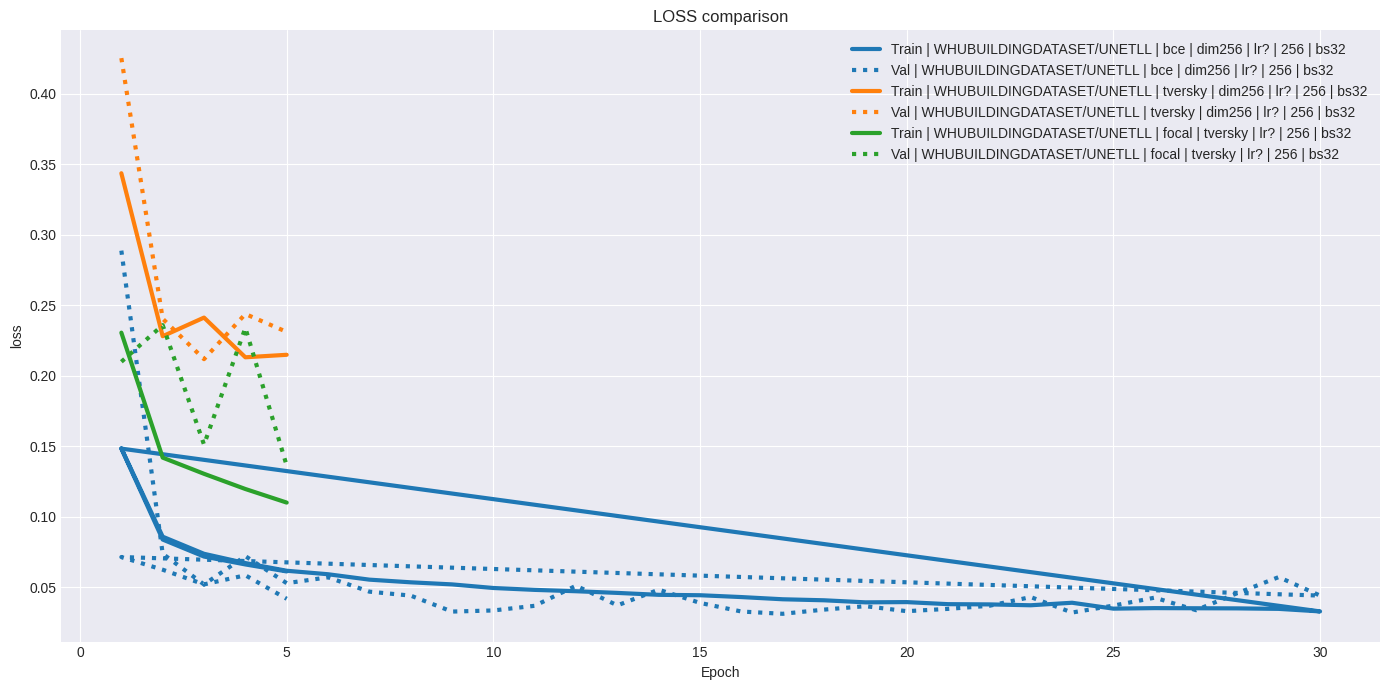

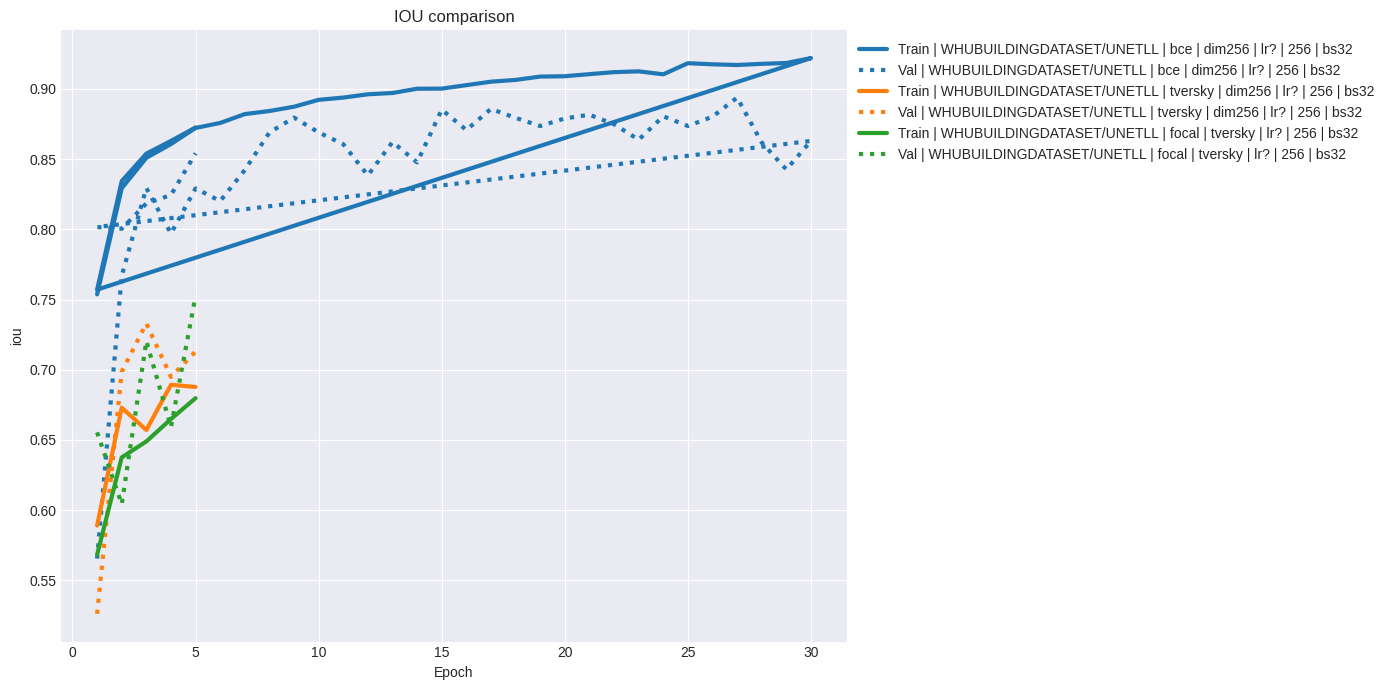

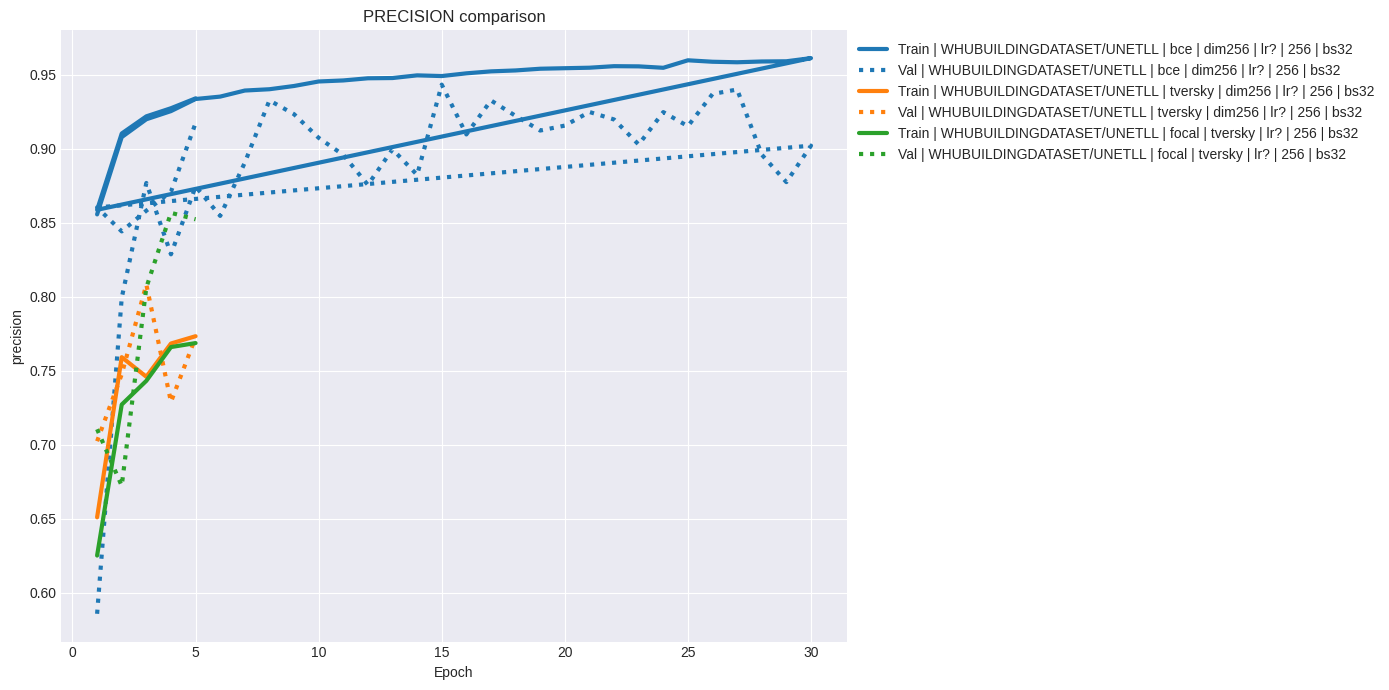

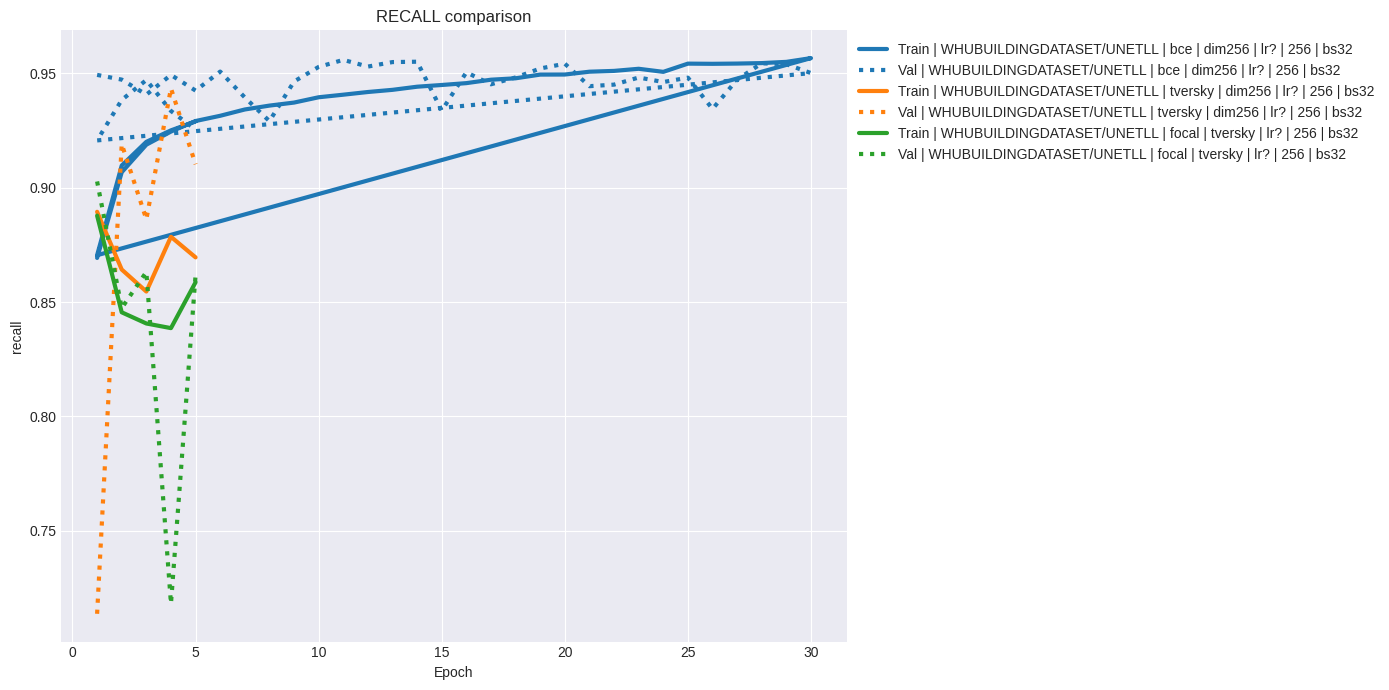

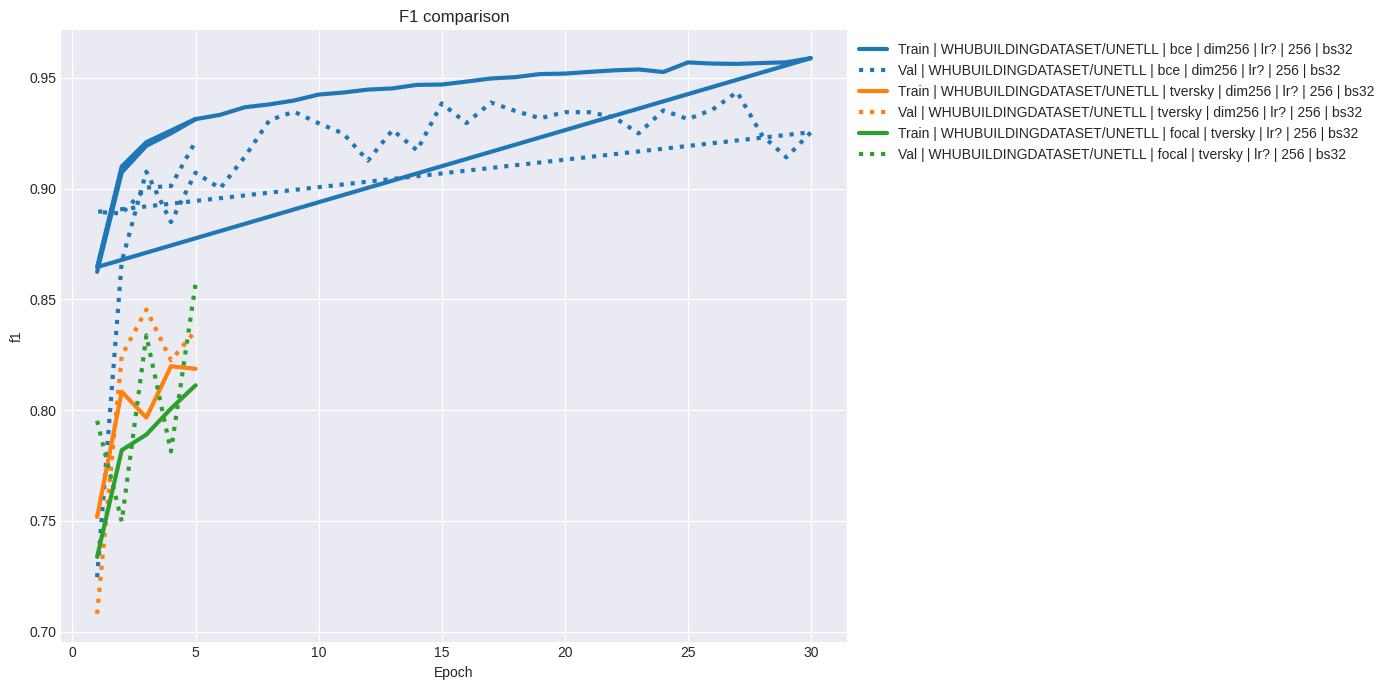

In [5]:
for metric in METRICS:

    plt.figure(figsize=(14,7))

    for idx, model in enumerate(models):

        df = runs[model]
        short = ShortModelName(model)

        plt.plot(
            df["epoch"],
            df[f"train_{metric}"],
            color=COLORS[idx],
            linewidth=3,
            linestyle='-',
            label=f"Train | {short}"
        )

        plt.plot(
            df["epoch"],
            df[f"val_{metric}"],
            color=COLORS[idx],
            linewidth=3,
            linestyle=':',
            label=f"Val | {short}"
        )

    plt.title(f"{metric.upper()} comparison")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1,1))
    plt.tight_layout()

    plt.show()

In [6]:
for model in models:

    df = runs[model]

    total_seconds = df['epoch_time_sec'].sum()
    hours, rem = divmod(total_seconds, 3600)
    minutes = rem // 60

    print(f"\n--------- {ShortModelName(model)} ---------")
    print(f"Time spent: {int(hours)}:{int(minutes):02d} hours ({df['epoch'].iloc[-1]} epochs)\n")

    print("FINAL VALUES")
    print(f"{'':8s} TRAIN      VALID")
    print(f"Loss    {df['train_loss'].iloc[-1]:.3f}     {df['val_loss'].iloc[-1]:.3f}")
    print(f"IoU     {df['train_iou'].iloc[-1]:.3f}     {df['val_iou'].iloc[-1]:.3f}")
    print(f"Prec    {df['train_precision'].iloc[-1]:.3f}     {df['val_precision'].iloc[-1]:.3f}")
    print(f"Recall  {df['train_recall'].iloc[-1]:.3f}     {df['val_recall'].iloc[-1]:.3f}")
    print(f"F1      {df['train_f1'].iloc[-1]:.3f}     {df['val_f1'].iloc[-1]:.3f}")


--------- WHUBUILDINGDATASET/UNETLL | bce | dim256 | lr? | 256 | bs32 ---------
Time spent: 1:07 hours (5 epochs)

FINAL VALUES
         TRAIN      VALID
Loss    0.061     0.042
IoU     0.873     0.854
Prec    0.934     0.917
Recall  0.929     0.925
F1      0.932     0.921

--------- WHUBUILDINGDATASET/UNETLL | tversky | dim256 | lr? | 256 | bs32 ---------
Time spent: 0:08 hours (5 epochs)

FINAL VALUES
         TRAIN      VALID
Loss    0.215     0.231
IoU     0.688     0.713
Prec    0.773     0.773
Recall  0.870     0.910
F1      0.819     0.836

--------- WHUBUILDINGDATASET/UNETLL | focal | tversky | lr? | 256 | bs32 ---------
Time spent: 0:08 hours (5 epochs)

FINAL VALUES
         TRAIN      VALID
Loss    0.110     0.136
IoU     0.680     0.753
Prec    0.769     0.852
Recall  0.859     0.862
F1      0.811     0.857


In [7]:
for model in models:

    df = runs[model]
    best_epoch = df["val_iou"].idxmax()

    print("\n", ShortModelName(model))
    print("Best epoch:", df.loc[best_epoch, "epoch"])
    print("Best Val IoU:", df.loc[best_epoch, "val_iou"])


 WHUBUILDINGDATASET/UNETLL | bce | dim256 | lr? | 256 | bs32
Best epoch: 27
Best Val IoU: 0.8937906755763254

 WHUBUILDINGDATASET/UNETLL | tversky | dim256 | lr? | 256 | bs32
Best epoch: 3
Best Val IoU: 0.7329838999137757

 WHUBUILDINGDATASET/UNETLL | focal | tversky | lr? | 256 | bs32
Best epoch: 5
Best Val IoU: 0.7526540311088987
